In [2]:
! pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# reproducibility
SEED = 42
np.random.seed(SEED)

# combining dataset
df = pd.concat([X, y], axis=1)
df = df.replace("?", np.nan)
print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Data exploration

We check how the three readmission classes are distributed. If one class dominates, a naive classifier could just always predict that class and still look decent on accuracy

In [4]:
print(df["readmitted"].value_counts())
print()
print(df["readmitted"].value_counts(normalize=True))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


We check which columns have missing data and how much. Columns with extremely high missing rates (like weight at ~97%) are essentially empty and trying to fill in that many values introduces more noise than signal. We'll drop those later.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


NO is the majority class at ~54%, >30 is ~35%, and <30 is only ~11%. This imbalance means our model will naturally lean toward predicting NO

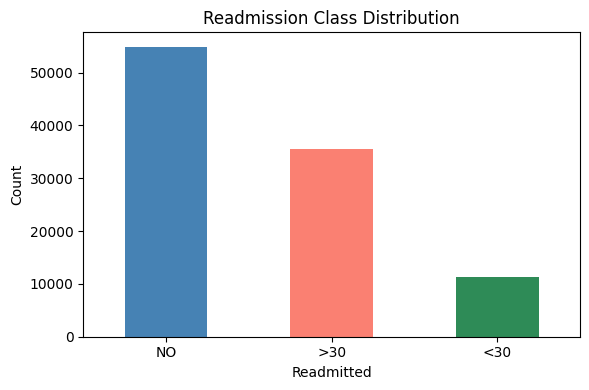

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "salmon", "seagreen"])
ax.set_title("Readmission Class Distribution")
ax.set_xlabel("Readmitted")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# drop ID columns if they exist
for col in ["encounter_id", "patient_nbr"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# drop columns with very high missing rates
high_missing = [col for col in df.columns if df[col].isnull().mean() > 0.40]
print(f"Dropping high-missing columns: {high_missing}")
df = df.drop(columns=high_missing)

X = df.drop(columns=["readmitted"])
y = df["readmitted"]

Dropping high-missing columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']


We split the data before any imputation or encoding to prevent data leakage. Data leakage is when information from the test set "leaks" into the training process. If we computed the mean using all the data and then split, the training set would contain information from the test set baked into those fill values. By splitting first, the test set stays truly unseen.

We use a 60/20/20 split: 60% for training, 20% for validation (hyperparameter tuning), and 20% for final testing (used only once at the end). We also use stratify=y to make sure each split has the same class proportions as the full dataset.


## imputing missing values
We fill in remaining missing values using statistics computed only from the training set, then apply those same values to the validation and test sets. Numeric columns get the training mean, and categorical columns get the training mode (most frequent value) since you can't average text like "Caucasian"

In [8]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val
)  # 0.25 of 80% = 20% of total

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}):  {numeric_cols[:5]} ...")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols[:5]} ...")

Train: 61059  Val: 20353  Test: 20354
Numeric features (11):  ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures'] ...
Categorical features (32): ['race', 'gender', 'age', 'payer_code', 'diag_1'] ...


In [9]:
# numeric: fill with training mean
train_means = X_train[numeric_cols].mean()
X_train[numeric_cols] = X_train[numeric_cols].fillna(train_means)
X_val[numeric_cols]   = X_val[numeric_cols].fillna(train_means)
X_test[numeric_cols]  = X_test[numeric_cols].fillna(train_means)

# categorical: fill with training mode
train_modes = X_train[categorical_cols].mode().iloc[0]
X_train[categorical_cols] = X_train[categorical_cols].fillna(train_modes)
X_val[categorical_cols]   = X_val[categorical_cols].fillna(train_modes)
X_test[categorical_cols]  = X_test[categorical_cols].fillna(train_modes)

In [10]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    # handle unseen labels in val/test by mapping to the most frequent class
    X_val[col]  = X_val[col].map(lambda v, _le=le: v if v in _le.classes_ else _le.classes_[0])
    X_test[col] = X_test[col].map(lambda v, _le=le: v if v in _le.classes_ else _le.classes_[0])
    X_val[col]  = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print("Label encoding complete.")
print(f"Remaining missing values — train: {X_train.isnull().sum().sum()}, "
      f"val: {X_val.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")

Label encoding complete.
Remaining missing values — train: 0, val: 0, test: 0


In [11]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Standardization complete.")
X_train.head()

Standardization complete.


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
76291,2,1,8,-0.707849,0.435996,0.311105,-0.469946,7,-1.639515,0.390360,...,0,0,1,1,0,0,0,0,0,1
24452,2,1,7,-0.707849,-0.134139,0.311105,1.540265,7,0.397996,-0.786066,...,0,0,3,1,0,0,0,0,0,1
54430,2,0,7,-0.707849,-0.514228,-1.172126,-1.140016,7,-1.741390,-0.786066,...,0,0,2,1,0,0,0,0,0,1
85512,0,1,5,0.682393,-0.514228,-1.172126,-0.804981,7,-1.435764,-0.786066,...,0,0,2,1,0,0,0,0,1,1
84580,2,0,5,0.682393,-0.514228,-1.172126,-0.469946,12,-0.773573,2.743213,...,0,0,3,1,0,0,0,0,0,1



## logistic regression
Hyperparameters we tune:

C: inverse of regularization strength. Smaller C = stronger regularization = simpler model. Like a volume knob for model complexity.
penalty — L1 (lasso, can zero out features) vs L2 (ridge, shrinks all features evenly).

Software: scikit-learn LogisticRegression with solver='saga'.

Hyperparameter Tuning on Validation Set
We train a model for every combination of penalty (L1, L2) and C (0.001 to 100), evaluate each on the validation set, and pick the best. This is like trying on different pairs of shoes and walking around the store — we test each option before committing.

In [12]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
penalties = ["l1", "l2"]

results = []

for pen in penalties:
    for c in C_values:
        model = LogisticRegression(
            C=c, penalty=pen, solver="saga",
            max_iter=5000, random_state=SEED, n_jobs=-1
        )
        model.fit(X_train, y_train)          # train on TRAINING set only
        
        train_acc = accuracy_score(y_train, model.predict(X_train))
        val_acc   = accuracy_score(y_val,   model.predict(X_val))
        
        results.append({
            "penalty": pen, "C": c,
            "train_acc": train_acc, "val_acc": val_acc
        })
        print(f"penalty={pen:>2s}  C={c:<7.3f}  "
              f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

results_df = pd.DataFrame(results)
print("\n--- Best by validation accuracy ---")
print(results_df.loc[results_df["val_acc"].idxmax()])

penalty=l1  C=0.001    train_acc=0.5650  val_acc=0.5658
penalty=l1  C=0.010    train_acc=0.5711  val_acc=0.5701
penalty=l1  C=0.100    train_acc=0.5710  val_acc=0.5708
penalty=l1  C=1.000    train_acc=0.5710  val_acc=0.5705
penalty=l1  C=10.000   train_acc=0.5711  val_acc=0.5705
penalty=l1  C=100.000  train_acc=0.5711  val_acc=0.5705
penalty=l2  C=0.001    train_acc=0.5708  val_acc=0.5699
penalty=l2  C=0.010    train_acc=0.5710  val_acc=0.5707
penalty=l2  C=0.100    train_acc=0.5710  val_acc=0.5704
penalty=l2  C=1.000    train_acc=0.5711  val_acc=0.5705
penalty=l2  C=10.000   train_acc=0.5711  val_acc=0.5705
penalty=l2  C=100.000  train_acc=0.5711  val_acc=0.5705

--- Best by validation accuracy ---
penalty            l1
C                 0.1
train_acc    0.571021
val_acc      0.570825
Name: 2, dtype: object


both curves are nearly on top of each other and flat; both low meaning that are model could be underfitting to the data.

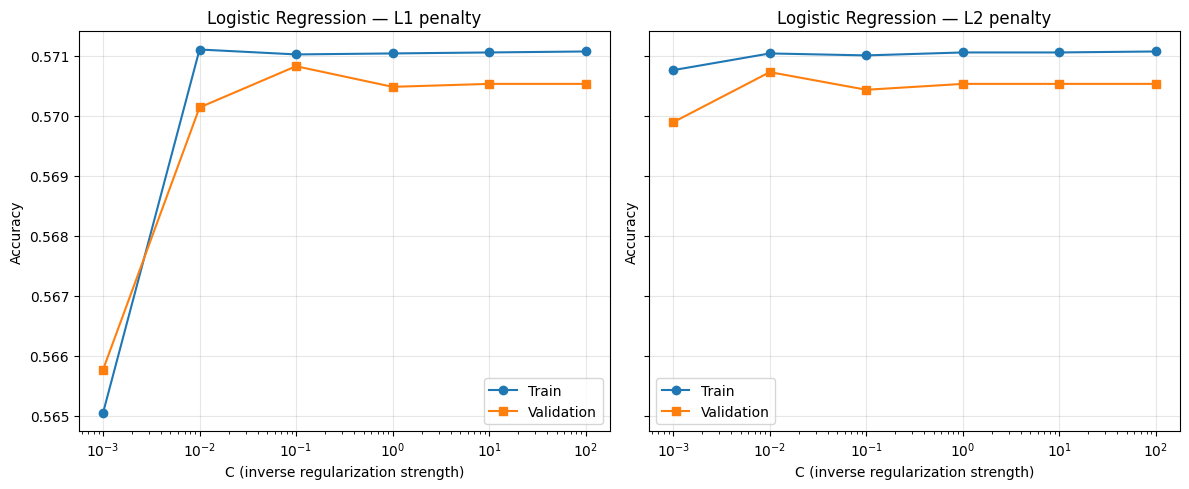

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, pen in enumerate(penalties):
    subset = results_df[results_df["penalty"] == pen]
    axes[i].plot(subset["C"], subset["train_acc"], "o-", label="Train")
    axes[i].plot(subset["C"], subset["val_acc"],   "s-", label="Validation")
    axes[i].set_xscale("log")
    axes[i].set_xlabel("C (inverse regularization strength)")
    axes[i].set_ylabel("Accuracy")
    axes[i].set_title(f"Logistic Regression — {pen.upper()} penalty")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We take the winning hyperparameters (L1, C=0.1) from validation, retrain on the combined train + validation data to squeeze out as much learning as possible, and evaluate once on the held-out test set. This single final evaluation gives us an honest, unbiased estimate of how the model would perform on truly new data

In [15]:
best_row = results_df.loc[results_df["val_acc"].idxmax()]
best_C   = best_row["C"]
best_pen = best_row["penalty"]
print(f"Best hyperparameters:  penalty={best_pen}, C={best_C}")

# retrain on train + val with the best hyperparameters
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = LogisticRegression(
    C=best_C, penalty=best_pen, solver="saga",
    max_iter=5000, random_state=SEED, n_jobs=-1
)
final_model.fit(X_train_full, y_train_full)

# evaluate on test set
y_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")

Best hyperparameters:  penalty=l1, C=0.1

Test Accuracy: 0.5698


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         <30       0.37      0.01      0.02      2272
         >30       0.49      0.24      0.33      7109
          NO       0.59      0.90      0.71     10973

    accuracy                           0.57     20354
   macro avg       0.48      0.38      0.35     20354
weighted avg       0.53      0.57      0.50     20354



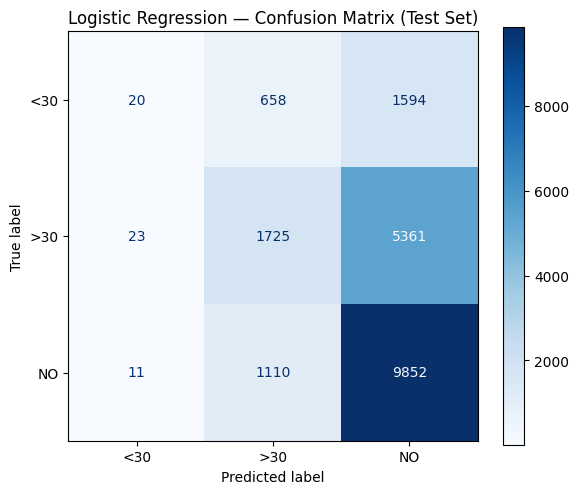

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Our model has low validation and training curves meaning our model is underfitting and could be a signal that our model is too simple and not predicting the data well.

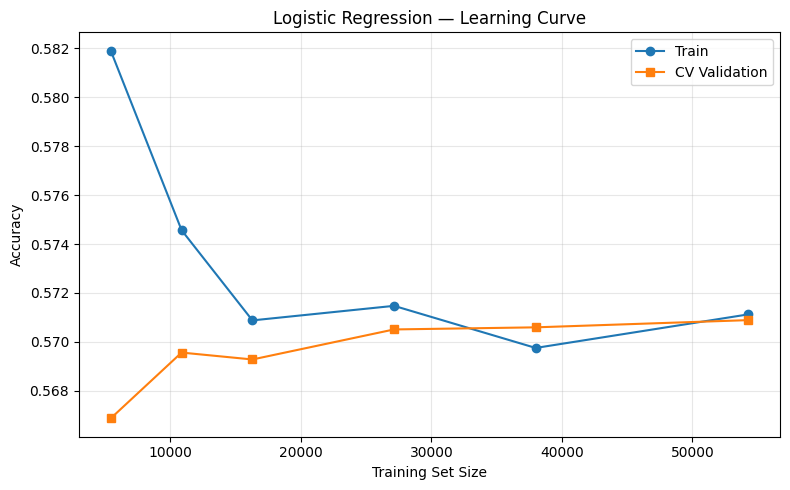

In [18]:
from sklearn.model_selection import learning_curve

train_sizes_frac = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

train_sizes_abs, train_scores, val_scores = learning_curve(
    LogisticRegression(C=best_C, penalty=best_pen, solver="saga",
                       max_iter=5000, random_state=SEED, n_jobs=-1),
    X_train_full, y_train_full,
    train_sizes=train_sizes_frac,
    cv=3, scoring="accuracy", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_abs, train_scores.mean(axis=1), "o-", label="Train")
ax.plot(train_sizes_abs, val_scores.mean(axis=1),   "s-", label="CV Validation")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.set_title("Logistic Regression — Learning Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()